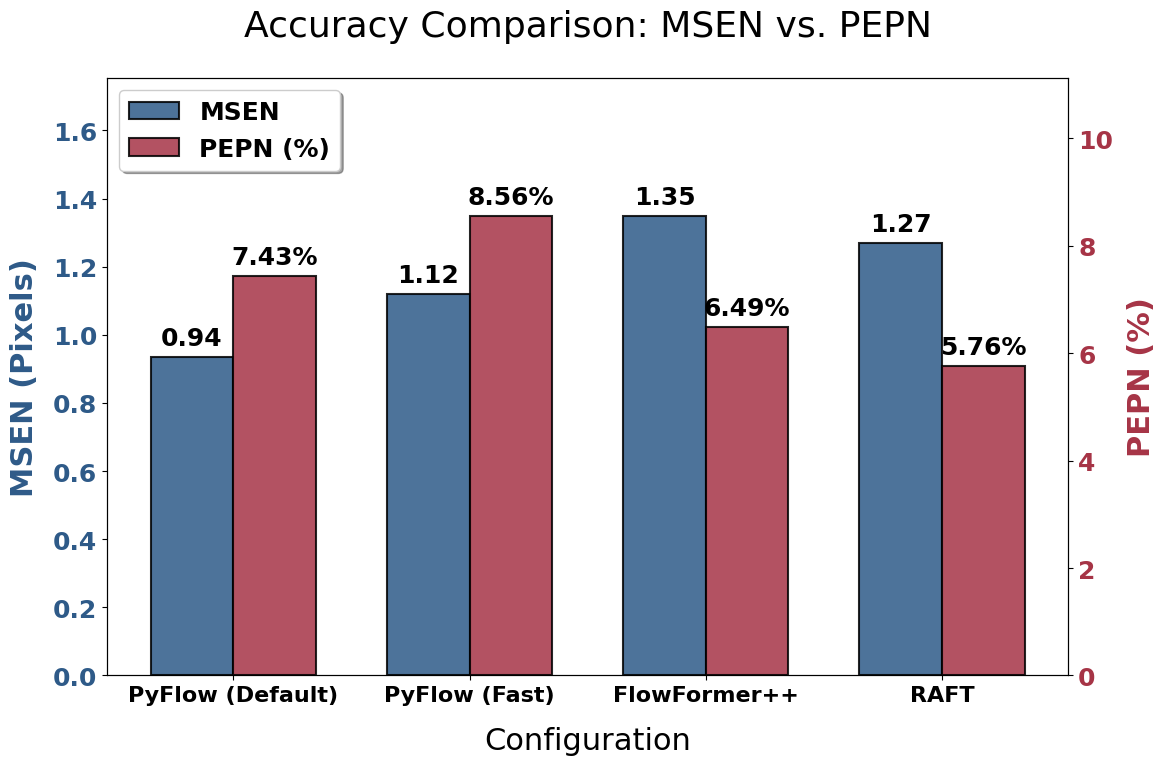

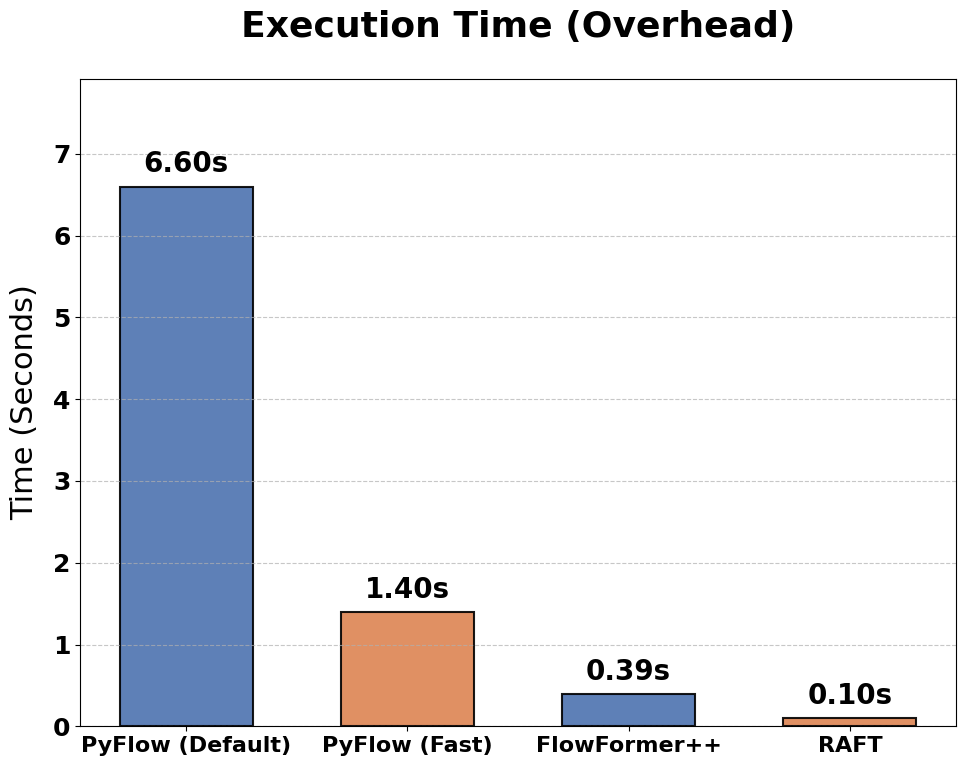

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION ---
configs = ['PyFlow (Default)', 'PyFlow (Fast)', 'FlowFormer++', 'RAFT']
msen_values = [0.936, 1.12, 1.35,1.27]
pepn_values = [7.43, 8.56, 6.49,5.76]
runtime_values = [6.6, 1.4, 0.39, 0.1]

x = np.arange(len(configs))  # Label locations
width = 0.35  # Width of the bars

# --- 2. GLOBAL STYLING ---
plt.rcParams.update({'font.size': 18, 'font.weight': 'bold'})

# --- 3. PLOT 1: ACCURACY (MSEN & PEPN with Dual Y-Axes) ---
fig, ax1 = plt.subplots(figsize=(12, 8))

# Left Y-axis: MSEN
color1 = '#2E5A88' # Deep Blue
bar1 = ax1.bar(x - width/2, msen_values, width, label='MSEN', color=color1, alpha=0.85, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Configuration', fontsize=22, labelpad=15)
ax1.set_ylabel('MSEN (Pixels)', color=color1, fontsize=22, fontweight='bold', labelpad=10)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, max(msen_values) * 1.3)

# Right Y-axis: PEPN
ax2 = ax1.twinx()  # Create second axis
color2 = '#A63446' # Crimson Red
bar2 = ax2.bar(x + width/2, pepn_values, width, label='PEPN (%)', color=color2, alpha=0.85, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('PEPN (%)', color=color2, fontsize=22, fontweight='bold', labelpad=10)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, max(pepn_values) * 1.3)
ax2.grid(False) # Avoid overlapping grid lines

# Aesthetics
plt.title('Accuracy Comparison: MSEN vs. PEPN', fontsize=26, pad=30)
ax1.set_xticks(x)
ax1.set_xticklabels(configs, fontsize=16)

# Value Labels
def add_labels(ax, bars, is_percent=False):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}{"%" if is_percent else ""}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

add_labels(ax1, bar1)
add_labels(ax2, bar2, is_percent=True)

# Unified Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=18, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# --- 4. PLOT 2: EFFICIENCY (Runtime) ---
plt.figure(figsize=(10, 8))
runtime_colors = ['#4C72B0', '#DD8452'] # Blue vs Orange

ax_rt = plt.bar(configs, runtime_values, color=runtime_colors, alpha=0.9, edgecolor='black', width=0.6, linewidth=1.5)

plt.title('Execution Time (Overhead)', fontsize=26, pad=30, fontweight='bold')
plt.ylabel('Time (Seconds)', fontsize=22, labelpad=10)
plt.ylim(0, max(runtime_values) * 1.2)

# Add values on top of bars
for i, v in enumerate(runtime_values):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center', va='bottom', fontsize=20, fontweight='bold')

plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()